# Módulo 10 tarefa 03
Considere a mesma base de dados utilizada na tarefa 1 ```previsao_de_renda.csv```.

1) Construa um gráfico de barras para avaliar a distribuição das variáveis qualitativas no tempo. Você acha que houve alguma alteração importante a ser investigada?

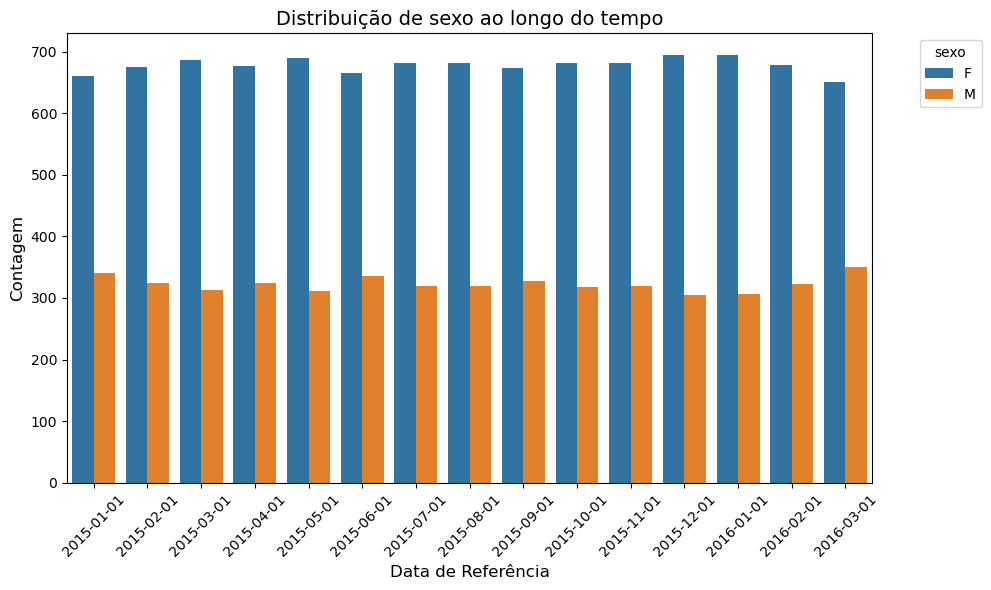

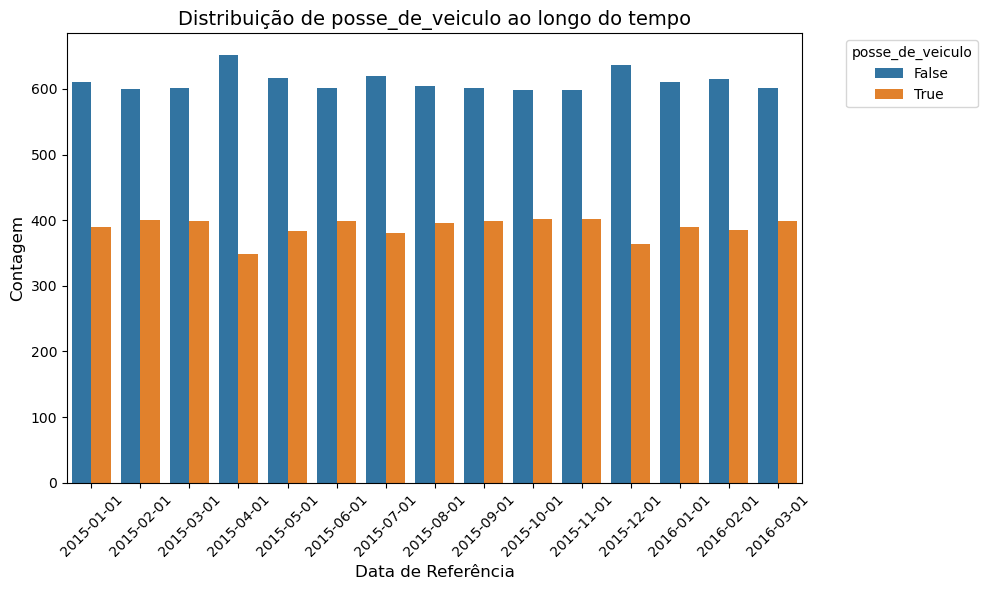

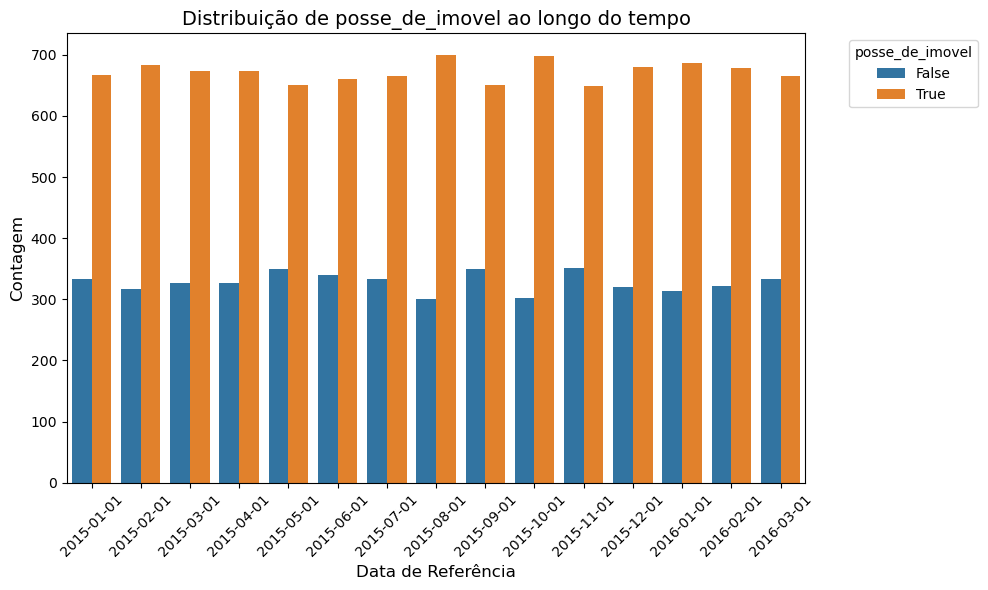

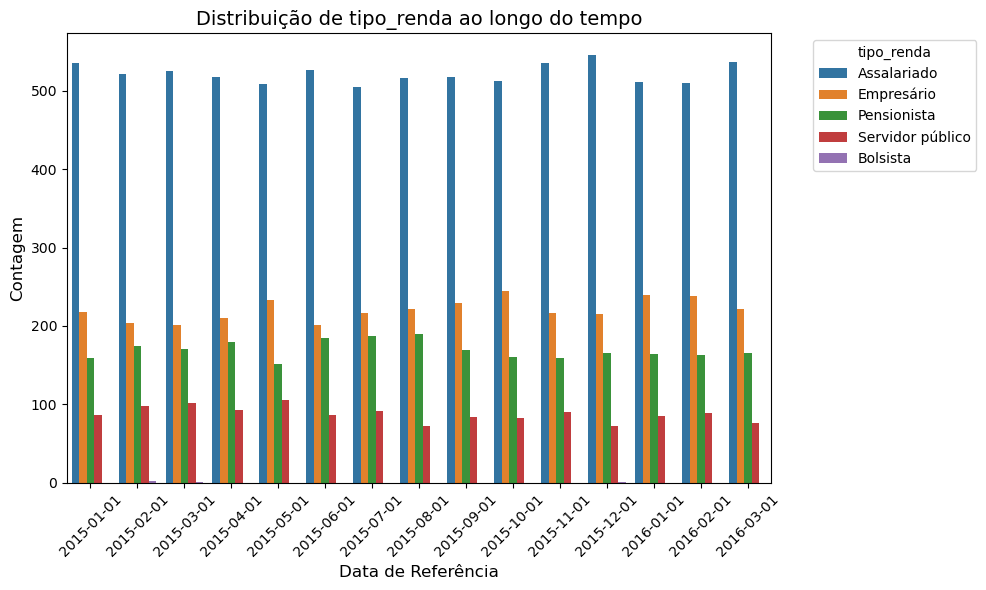

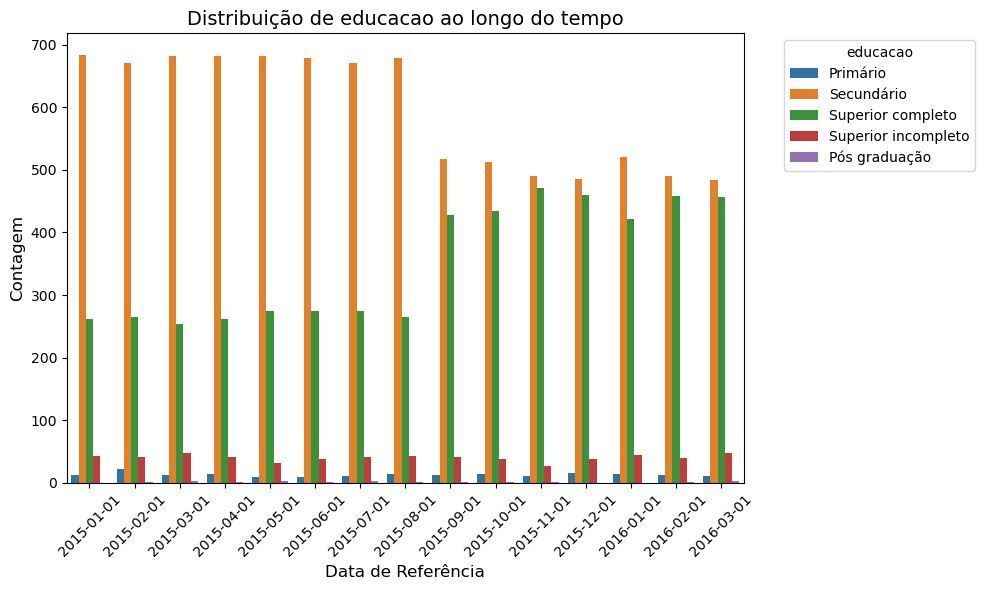

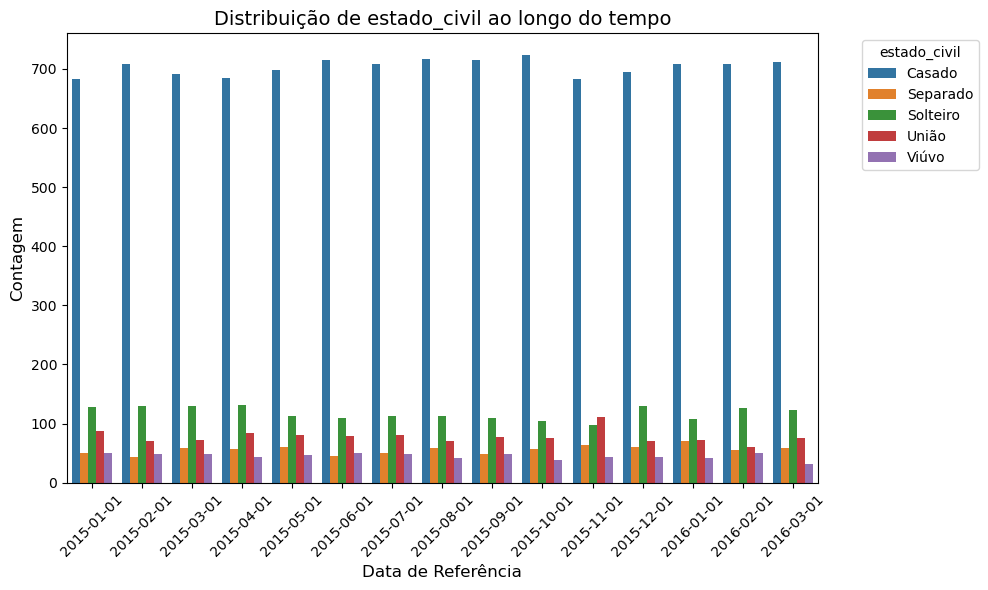

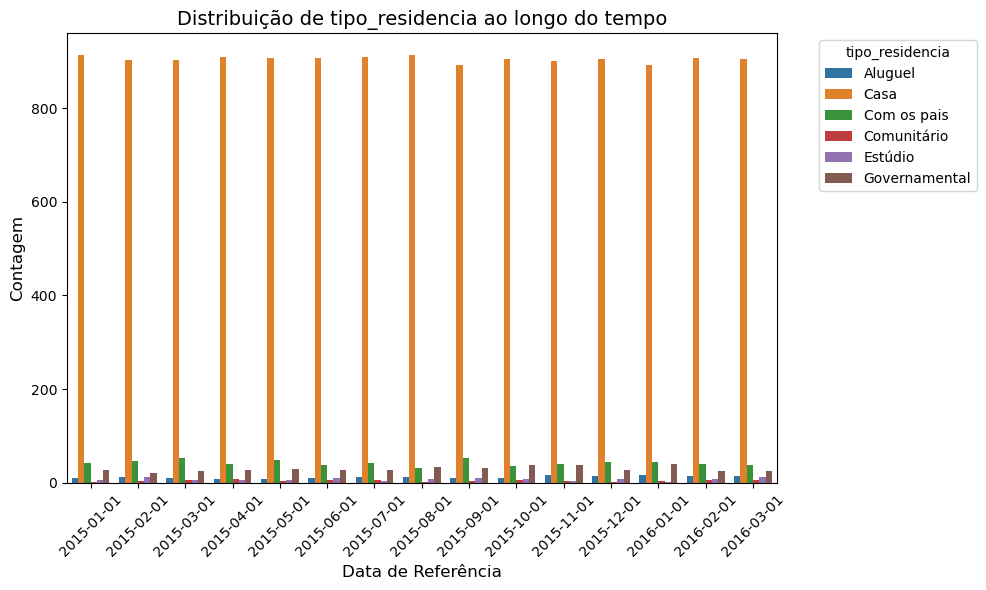

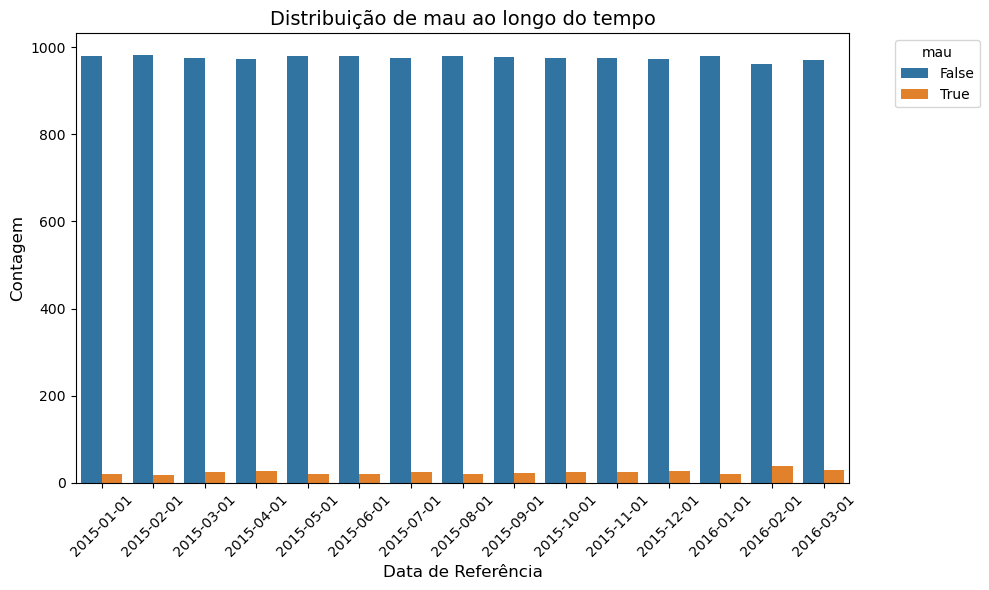

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

df = pd.read_csv ('C://Users/fabio.stampone/Documents/EBAC/Mod10/Pratique2/Base.csv')

# Converter a coluna 'data_ref' para datetime
df['data_ref'] = pd.to_datetime(df['data_ref'])

# Selecionar as variáveis qualitativas para análise
qualitative_columns = ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 
                       'tipo_renda', 'educacao', 'estado_civil', 
                       'tipo_residencia', 'mau']

# Criar gráficos de barras para cada variável qualitativa
for col in qualitative_columns:
    plt.figure(figsize=(10, 6))
    data_grouped = df.groupby(['data_ref', col]).size().reset_index(name='counts')
    sns.barplot(data=data_grouped, x='data_ref', y='counts', hue=col)
    plt.title(f'Distribuição de {col} ao longo do tempo', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('Contagem', fontsize=12)
    plt.xlabel('Data de Referência', fontsize=12)
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Houve variações significativas em "tipo_renda", "educacao" e "mau" ao longo do tempo, indicando possíveis mudanças no perfil socioeconômico e na inadimplência. Alterações em "posse_de_veiculo" e "posse_de_imovel" também sugerem transformações financeiras ou tendências no mercado. Essas mudanças merecem investigação para compreender suas causas e impactos.

2) Para cada variável qualitativa, construa um gráfico mostrando as médias de cada nível da variável no tempo e avalie a estabilidade. Houve alguma alteração importante? Você acha que se pode utilizar essas variáveis em uma modelagem?

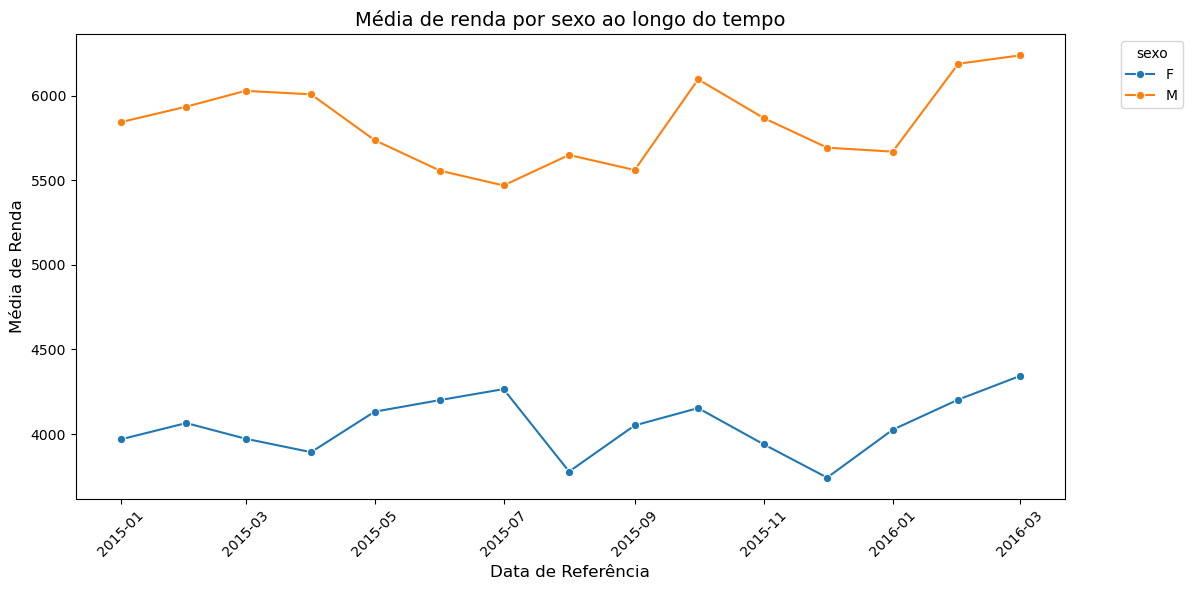

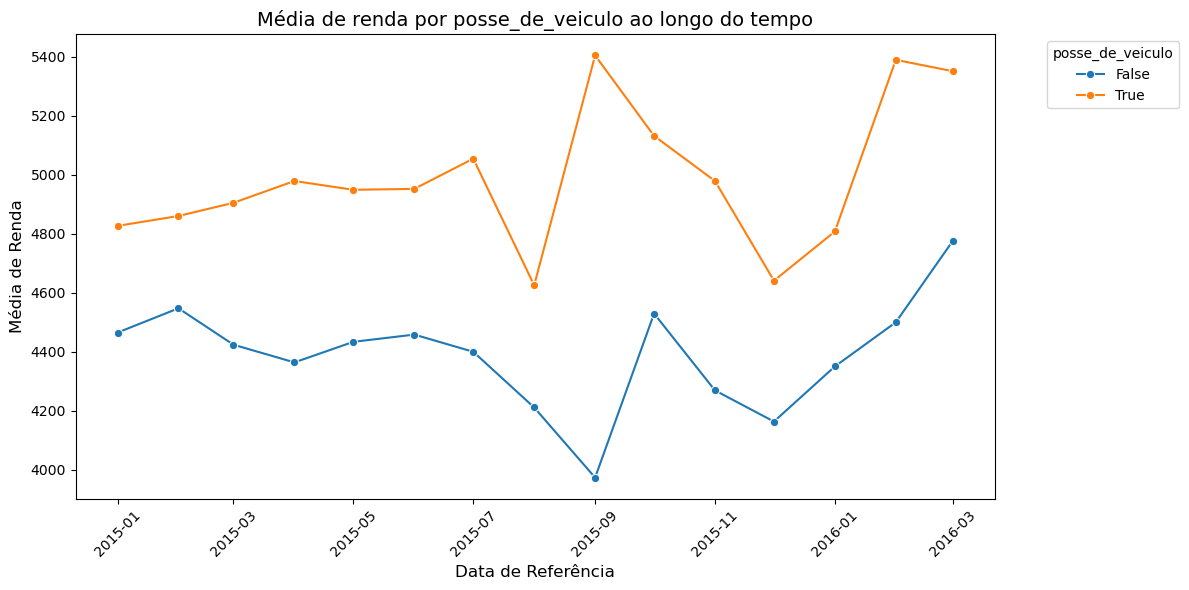

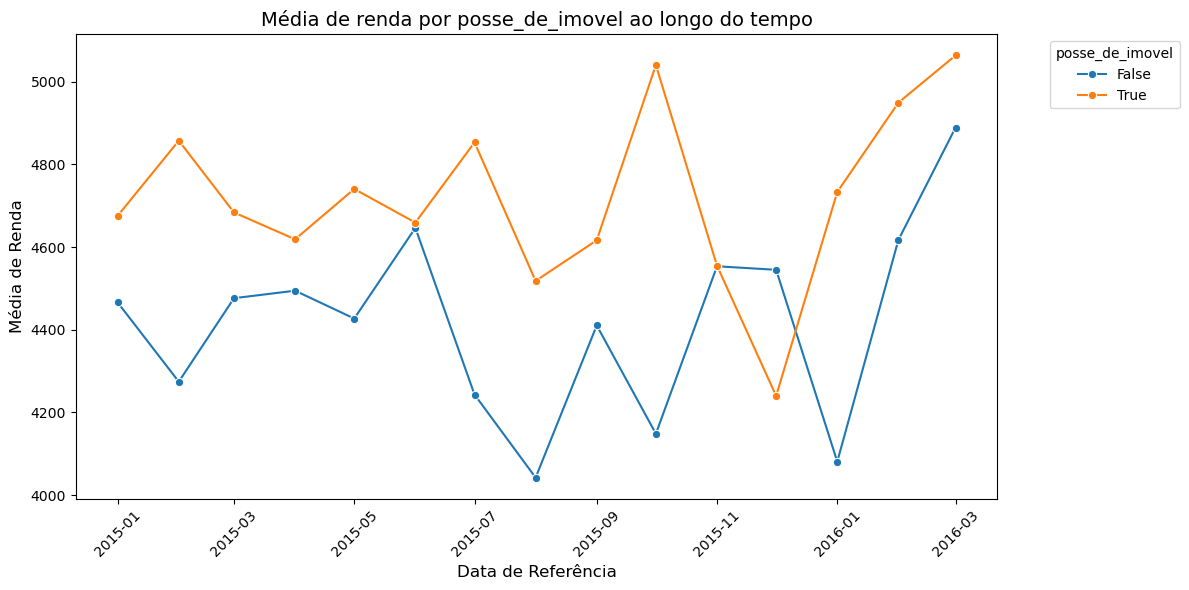

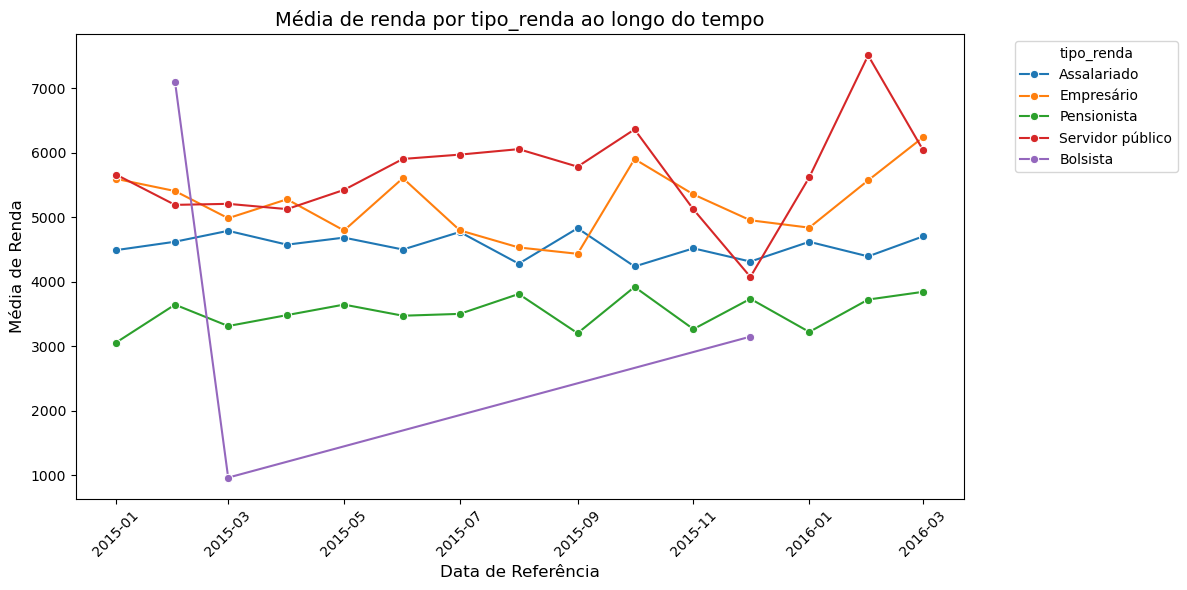

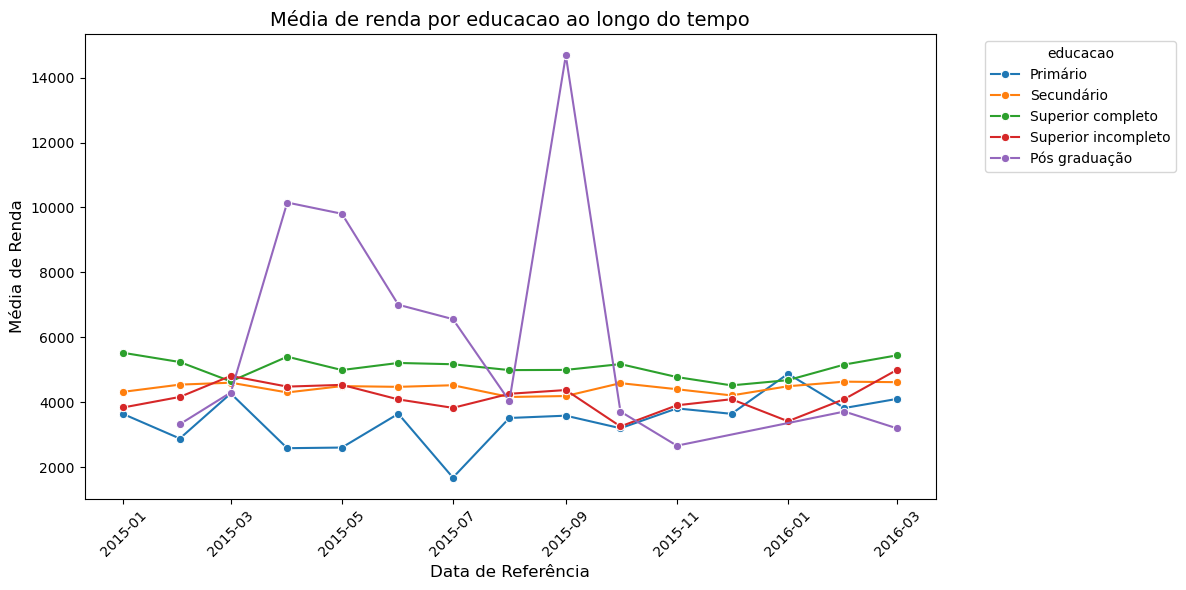

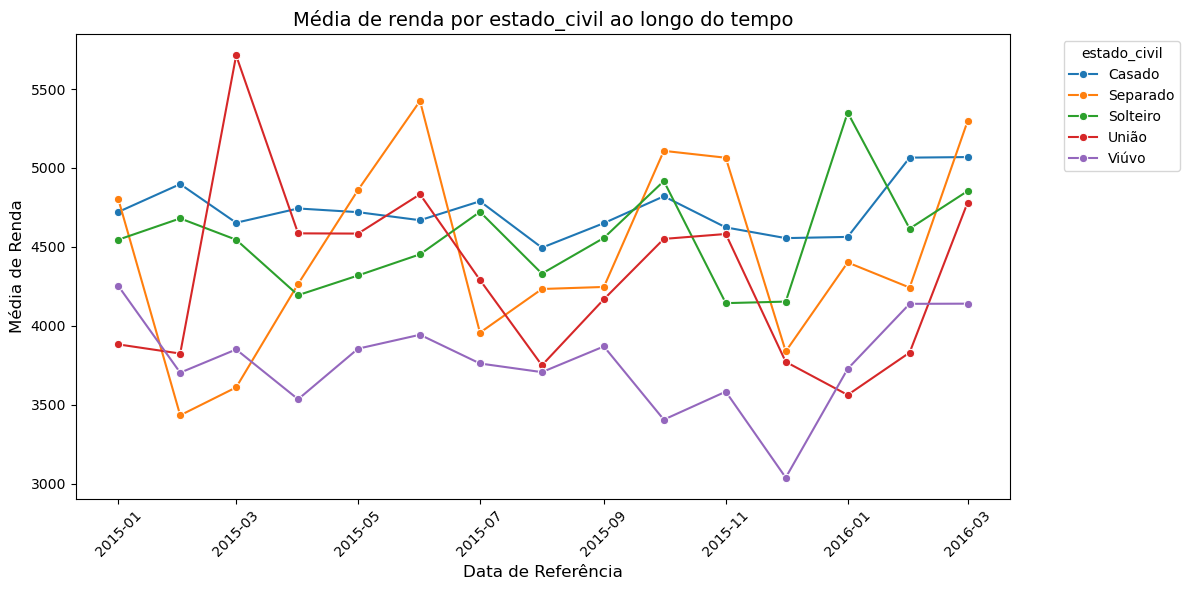

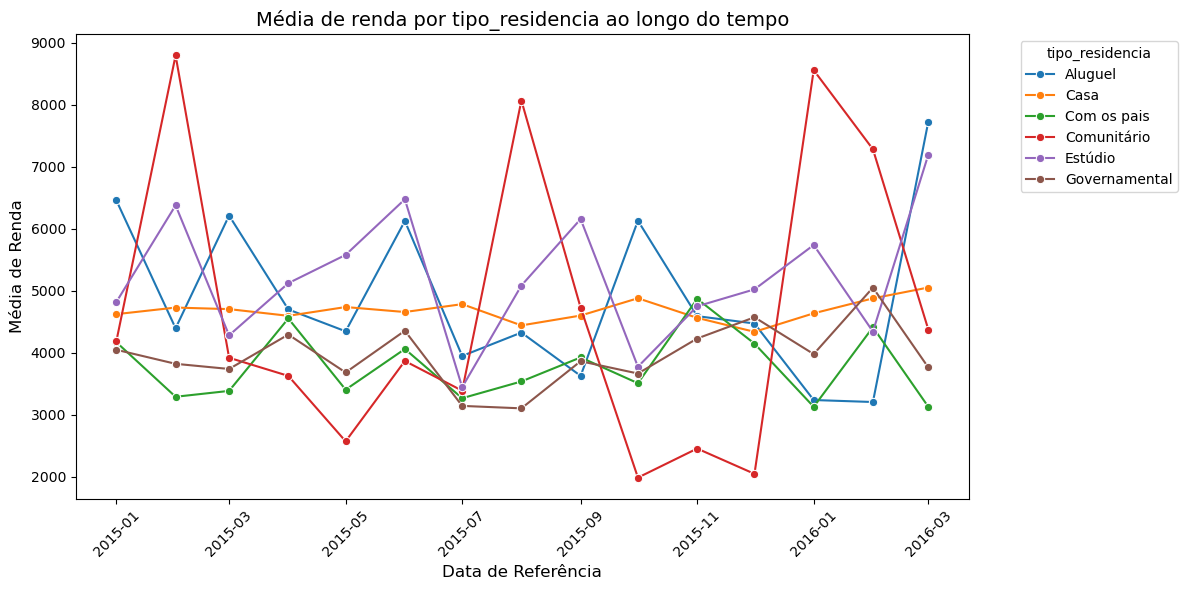

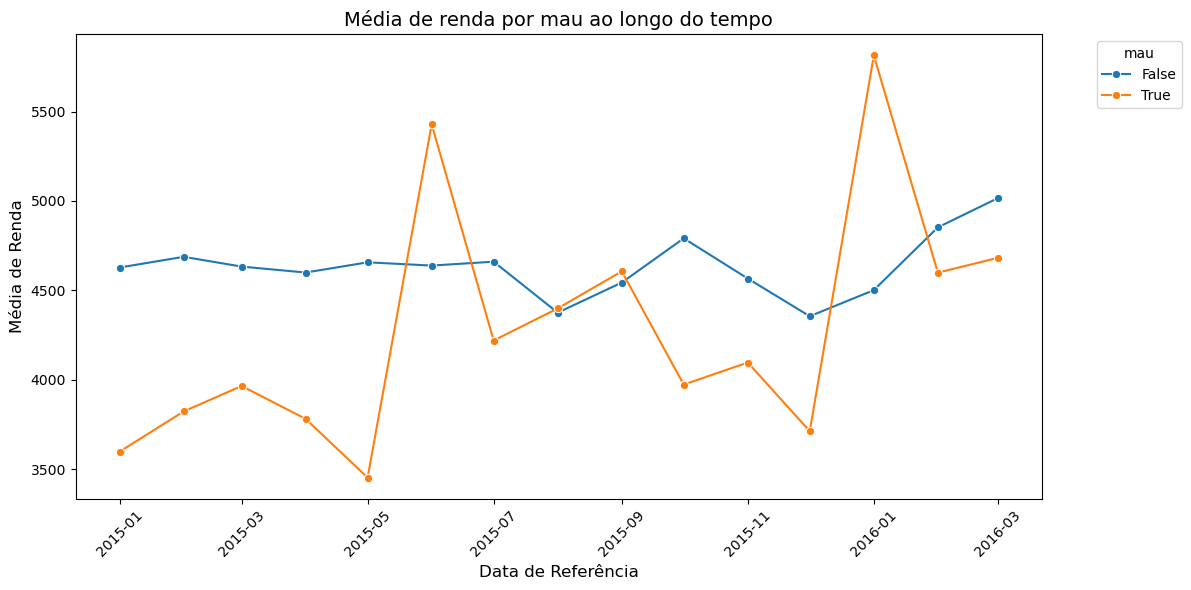

In [5]:
# Definir as variáveis qualitativas
variaveis_qualitativas = ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 
                          'tipo_renda', 'educacao', 'estado_civil', 
                          'tipo_residencia', 'mau']

# Calcular e plotar a média de renda para cada nível das variáveis qualitativas ao longo do tempo
for coluna in variaveis_qualitativas:
    plt.figure(figsize=(12, 6))
    
    # Calcular a média de renda agrupada por 'data_ref' e pela variável qualitativa
    media_dados = df.groupby(['data_ref', coluna])['renda'].mean().reset_index()
    
    # Plotar o gráfico
    sns.lineplot(data=media_dados, x='data_ref', y='renda', hue=coluna, marker='o')
    plt.title(f'Média de renda por {coluna} ao longo do tempo', fontsize=14)
    plt.xlabel('Data de Referência', fontsize=12)
    plt.ylabel('Média de Renda', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title=coluna, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

As variáveis apresentam oscilações importantes, como diferenças de renda por "tipo_renda" e "educacao", e impacto claro de "mau" (inadimplência). Variáveis como "sexo" e "estado_civil" são mais estáveis. Elas podem ser usadas em modelagem preditiva, mas exigem pré-processamento, como codificação e análise de correlações. Há potencial para prever renda ou inadimplência, mas é necessário validar a relevância e consistência dessas variáveis no modelo.